Import dataset and libraries

In [2]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s6e8')

print("Path to competition files:", path)

100%|██████████| 19.7M/19.7M [00:00<00:00, 123MB/s] 

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/playground-series-s6e8


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, PredefinedSplit, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from lightgbm import LGBMClassifier
!pip install -q catboost
from catboost import CatBoostClassifier
import lightgbm as lgb
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
import joblib

Loading dataset and preliminary EDA


In [4]:
train = pd.read_csv('/root/.cache/kagglehub/competitions/playground-series-s6e8/train.csv')
train.drop('id', axis = 1, inplace = True)
train.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [5]:
test = pd.read_csv('/root/.cache/kagglehub/competitions/playground-series-s6e8/test.csv')
test_ids = test['id']
test.drop('id', axis = 1, inplace = True)
test.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No


In [ ]:
train.shape

(691369, 13)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      662440 non-null  float64
 1   daily_screen_time_hours  595515 non-null  float64
 2   social_media_hours       557374 non-null  float64
 3   gaming_hours             564548 non-null  float64
 4   work_study_hours         639851 non-null  float64
 5   sleep_hours              646889 non-null  float64
 6   notifications_per_day    623785 non-null  float64
 7   app_opens_per_day        610659 non-null  float64
 8   weekend_screen_time      579306 non-null  float64
 9   gender                   662335 non-null  object 
 10  stress_level             636221 non-null  object 
 11  academic_work_impact     647145 non-null  object 
 12  addicted_label           691369 non-null  int64  
dtypes: float64(9), int64(1), object(3)
memory usage: 68.6+ MB


Data type conversion

In [6]:
train.age = train.age.astype('Int64', errors = 'ignore')
train.notifications_per_day = train.notifications_per_day.astype('Int64', errors = 'ignore')
train.app_opens_per_day = train.app_opens_per_day.astype('Int64', errors = 'ignore')
train.gender = train.gender.astype('category', errors = 'ignore')
train.stress_level = train.stress_level.astype('category', errors = 'ignore')
train.academic_work_impact = train.academic_work_impact.astype('category', errors = 'ignore')
train.addicted_label = train.addicted_label.astype('category', errors = 'ignore')

test.age = test.age.astype('Int64', errors = 'ignore')
test.notifications_per_day = test.notifications_per_day.astype('Int64', errors = 'ignore')
test.app_opens_per_day = test.app_opens_per_day.astype('Int64', errors = 'ignore')
test.gender = test.gender.astype('category', errors = 'ignore')
test.stress_level = test.stress_level.astype('category', errors = 'ignore')
test.academic_work_impact = test.academic_work_impact.astype('category', errors = 'ignore')

In [ ]:
train.isna().sum()

,0
age,28929
daily_screen_time_hours,95854
social_media_hours,133995
gaming_hours,126821
work_study_hours,51518
sleep_hours,44480
notifications_per_day,67584
app_opens_per_day,80710
weekend_screen_time,112063
gender,29034


In [7]:
x_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

## Attempt to ascertain how to deal with NANs

Check for MAR (relationship between categories where there are missing values)

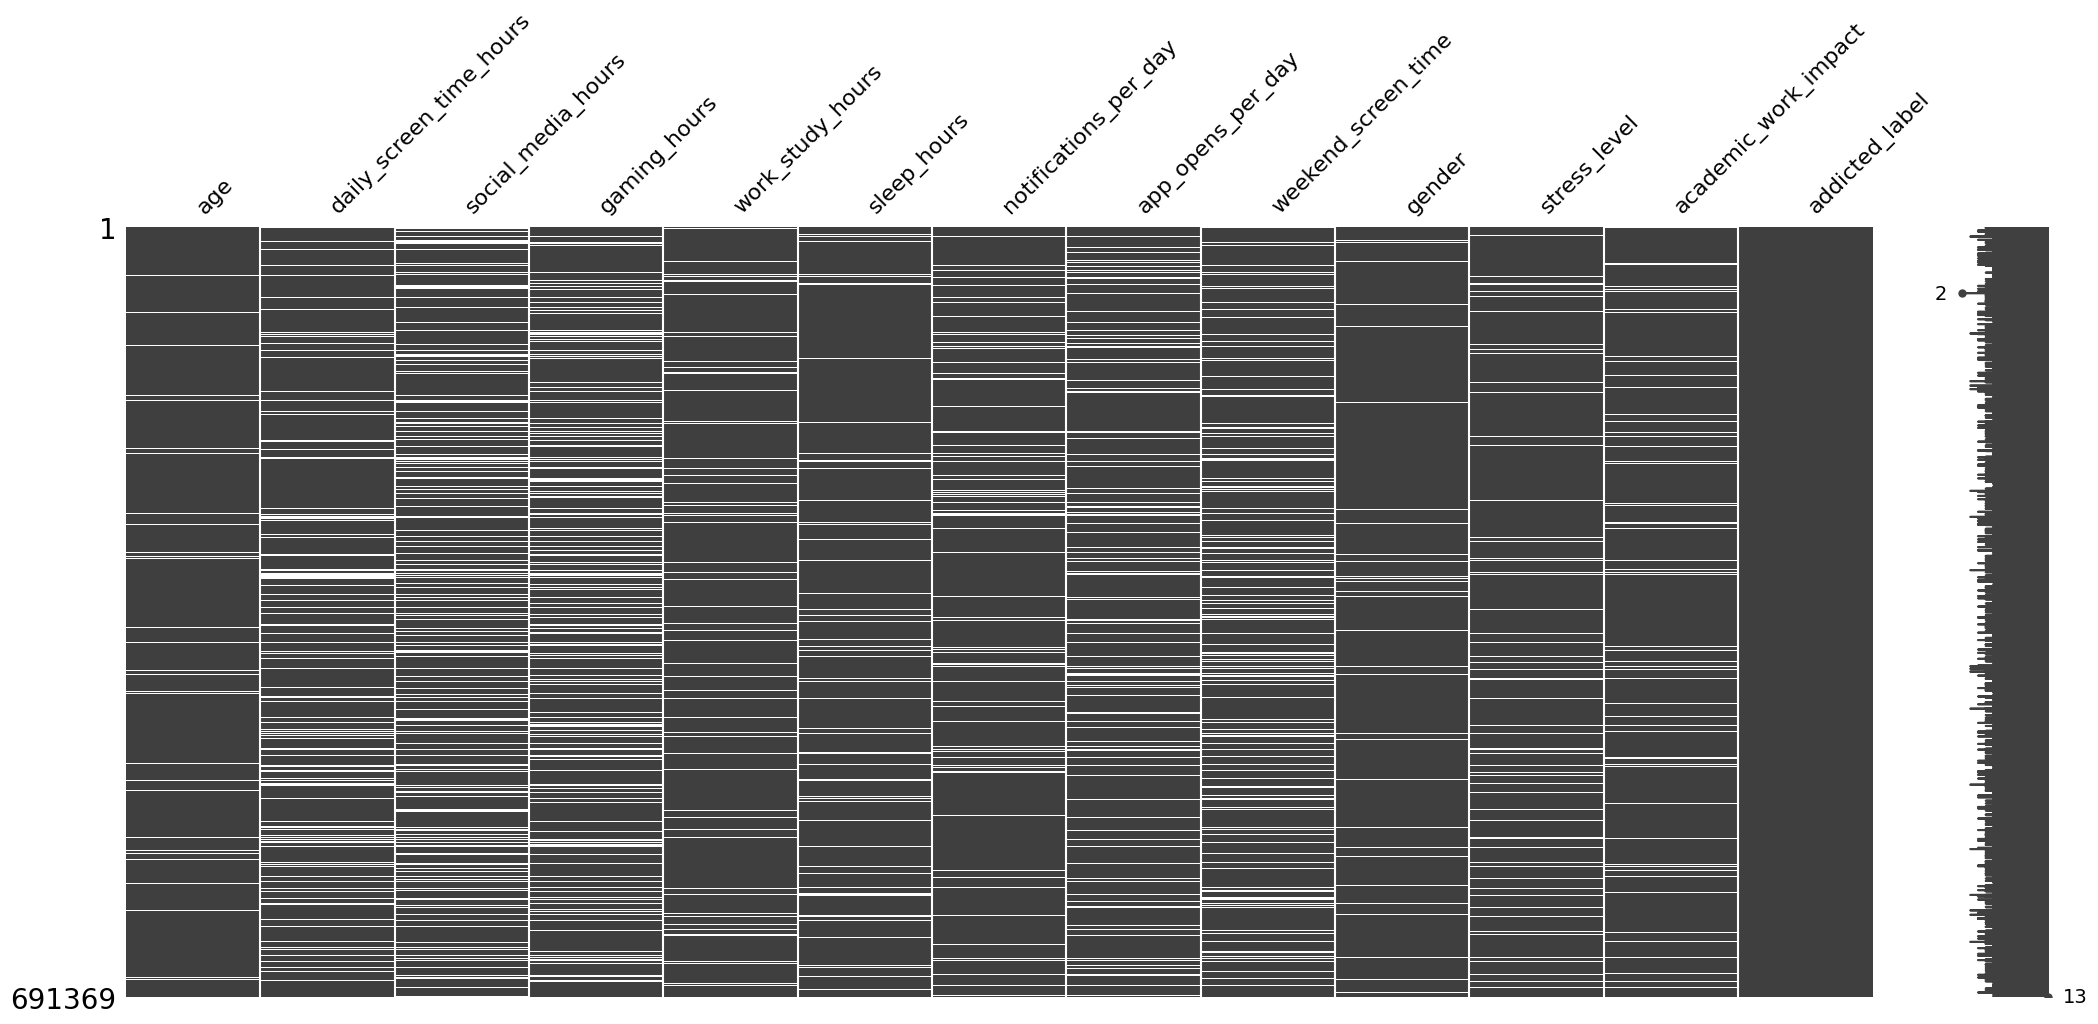

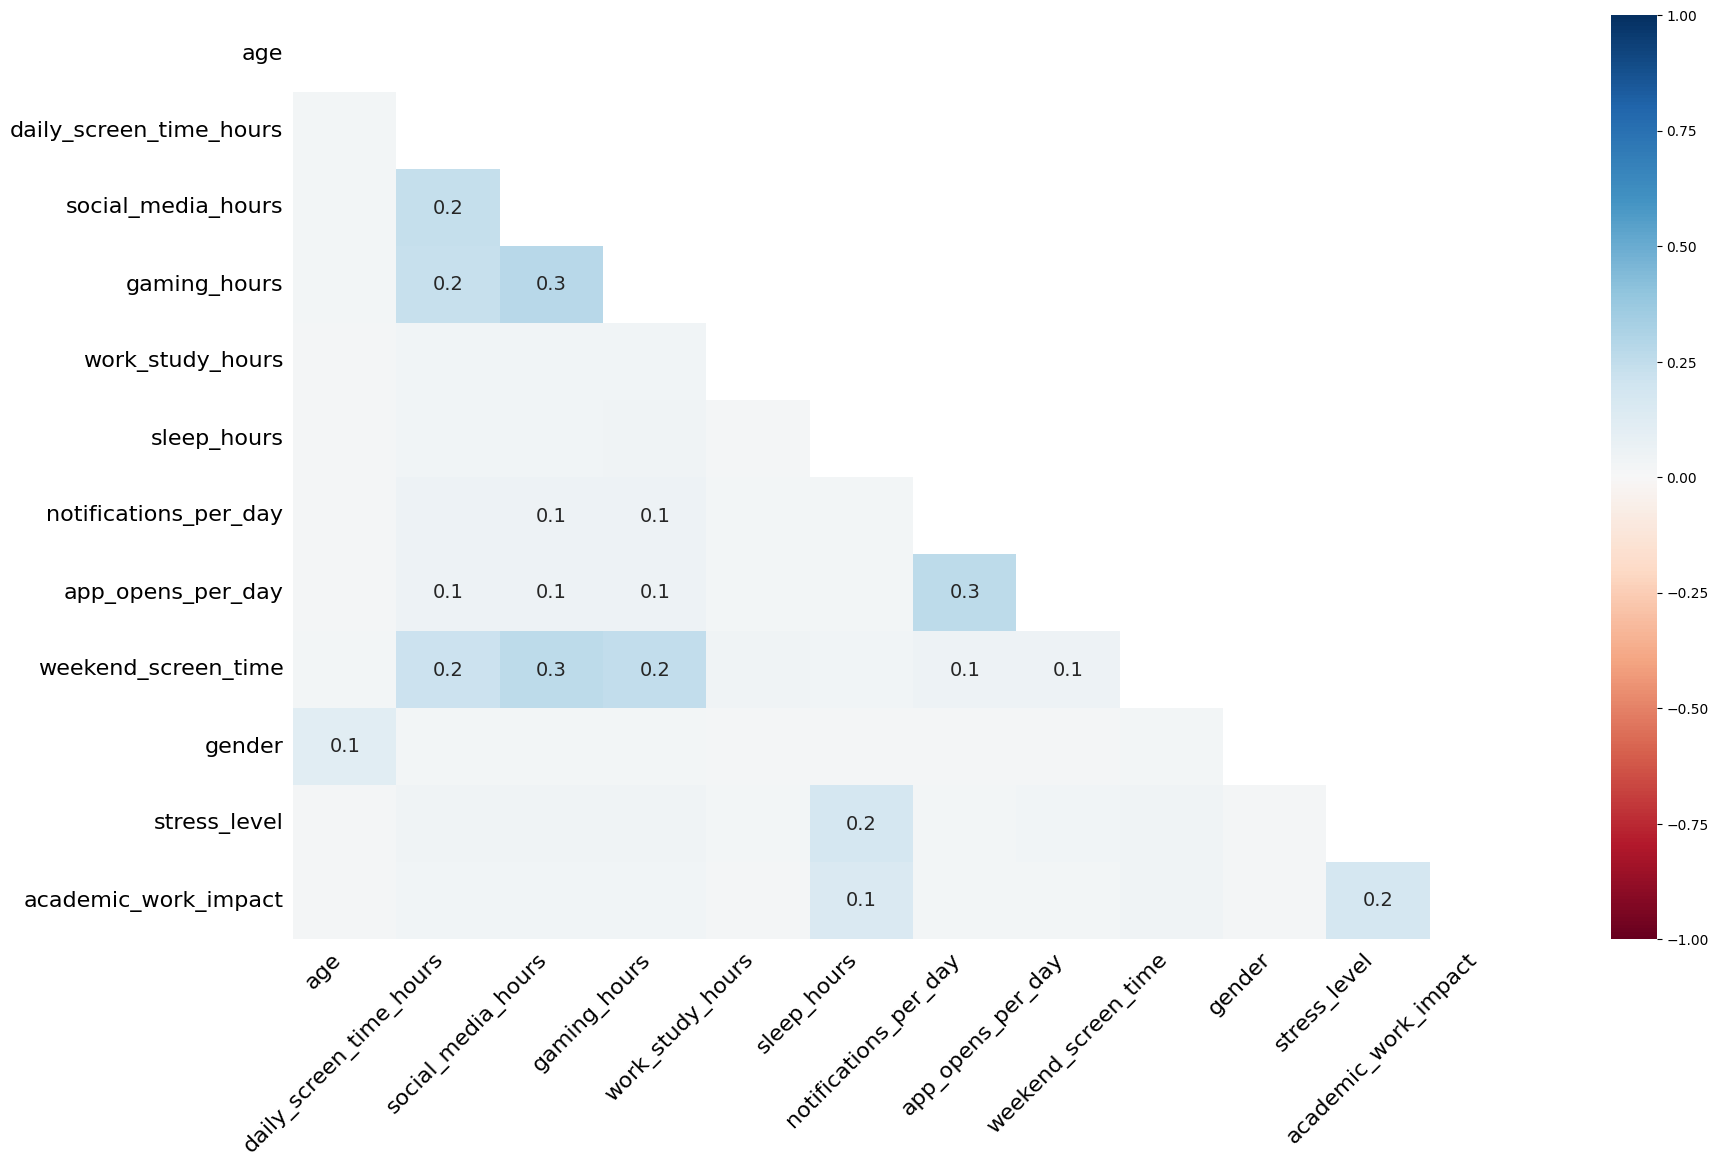

In [ ]:
import missingno as msno
msno.matrix(train)
plt.show()

msno.heatmap(train)
plt.show()

Check for MCAR

In [ ]:
!pip install -q pingouin
import pingouin as pg

def missing_test(df):
  results = []

  cols_with_missing = list(df.columns[df.isna().any()])

  for col_with_missing in cols_with_missing:
    categorical_missing = df[col_with_missing].isna().astype(int)

    other_cols = [col for col in df.columns if col != col_with_missing]

    for col in other_cols:
      temp = pd.DataFrame({
          'missing': categorical_missing,
          'other': df[col]
      }).dropna(axis = 0, subset = ['other'])

      if temp['missing'].nunique() < 2:
        continue

      try:
        if pd.api.types.is_numeric_dtype(df[col]):
          group_0 = temp.loc[temp['missing'] == 0, 'other']
          group_1 = temp.loc[temp['missing'] == 1, 'other']

          ttest_result = pg.ttest(group_0, group_1)
          results.append({
              'missing col': col_with_missing,
              'other': col,
              'test': 't-test',
              'p val': ttest_result['p_val'].values[0]
          })
        else:
          expected, observed, stats = pg.chi2_independence(
              data = temp,
              x = 'missing',
              y = 'other'
          )
          results.append({
              'missing col': col_with_missing,
              'other': col,
              'test': 'chisq-test',
              'p val': stats.loc[stats['test'] == 'pearson', 'pval'].values[0]
          })
      except Exception as e:
        print(f"{col_with_missing} vs {col}: {type(e).__name__}: {e}")
        results.append({
              'missing col': col_with_missing,
              'other': col,
              'test': 'failed',
              'p val': None
          })
  return pd.DataFrame(results)

results_df = missing_test(train)
results_df

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 18.0 MB/s eta 0:00:00


,missing col,other,test,p val
0,age,daily_screen_time_hours,t-test,0.085661
1,age,social_media_hours,t-test,0.504280
2,age,gaming_hours,t-test,0.947909
3,age,work_study_hours,t-test,0.995367
4,age,sleep_hours,t-test,0.533443
...,...,...,...,...
139,academic_work_impact,app_opens_per_day,t-test,0.189540
140,academic_work_impact,weekend_screen_time,t-test,0.080890
141,academic_work_impact,gender,chisq-test,0.294720
142,academic_work_impact,stress_level,chisq-test,0.218873


In [ ]:
from statsmodels.stats.multitest import multipletests
results_df['p adj'] = multipletests(results_df['p val'].dropna(), method = 'fdr_bh')[1]
results_df.loc[results_df['p adj'] < 0.05, :]

,missing col,other,test,p val,p adj
12,daily_screen_time_hours,age,t-test,1.205020e-95,4.338072e-94
24,social_media_hours,age,t-test,1.080035e-113,1.555250e-111
36,gaming_hours,age,t-test,1.043440e-112,7.512766e-111
48,work_study_hours,age,t-test,5.458679e-33,7.860498e-32
60,sleep_hours,age,t-test,9.431044e-35,1.508967e-33
61,sleep_hours,daily_screen_time_hours,t-test,6.437636e-04,7.725163e-03
72,notifications_per_day,age,t-test,6.343368e-65,1.522408e-63
73,notifications_per_day,daily_screen_time_hours,t-test,4.307907e-03,4.430990e-02
84,app_opens_per_day,age,t-test,3.642226e-68,1.048961e-66
96,weekend_screen_time,age,t-test,2.249062e-104,1.079550e-102


## Going with ML methods that automatically handle NANs

### XGBoost

Early stopping (used to determine range for hyper-parameter finetuning)

In [8]:
x_train_fit, x_validation, y_train_fit, y_validation = train_test_split(
    x_train, y_train, test_size = 0.10, random_state = 42, stratify = y_train
)

In [11]:
xgb_model = XGBClassifier(
    objective = 'binary:logistic',
    eval_metric = 'auc',
    enable_categorical = True,
    random_state = 42,
    n_estimators = 5000,
    early_stopping_rounds = 20
)

xgb_model.fit(
    x_train_fit, y_train_fit,
    eval_set = [(x_validation, y_validation)],
    verbose = 10
)

print(xgb_model.best_iteration)

[0]	validation_0-auc:0.92579
[10]	validation_0-auc:0.93503
[20]	validation_0-auc:0.94216
[30]	validation_0-auc:0.94864
[40]	validation_0-auc:0.95297
[50]	validation_0-auc:0.95465
[60]	validation_0-auc:0.95617
[70]	validation_0-auc:0.95705
[80]	validation_0-auc:0.95789
[90]	validation_0-auc:0.95860
[100]	validation_0-auc:0.95930
[110]	validation_0-auc:0.95989
[120]	validation_0-auc:0.96048
[130]	validation_0-auc:0.96061
[140]	validation_0-auc:0.96078
[150]	validation_0-auc:0.96104
[160]	validation_0-auc:0.96132
[170]	validation_0-auc:0.96148
[180]	validation_0-auc:0.96156
[190]	validation_0-auc:0.96169
[200]	validation_0-auc:0.96177
[210]	validation_0-auc:0.96186
[220]	validation_0-auc:0.96191
[230]	validation_0-auc:0.96198
[240]	validation_0-auc:0.96202
[250]	validation_0-auc:0.96207
[260]	validation_0-auc:0.96210
[270]	validation_0-auc:0.96209
[271]	validation_0-auc:0.96209
251


Cross Validation

In [12]:
cv_xgb_model = XGBClassifier(
    objective = 'binary:logistic',
    eval_metric = 'auc',
    enable_categorical = True,
    random_state = 42,
    n_estimators = xgb_model.best_iteration
)

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
cv_scores = cross_val_score(cv_xgb_model, x_train, y_train, cv = cv, scoring = 'roc_auc')

print(cv_scores)
print(f'Mean CV AUC: {cv_scores.mean(): .4f}')

[0.96221032 0.96295968 0.96351679 0.9637947  0.96257315]
Mean CV AUC:  0.9630


Hyper-parameter fine-tuning (using GPU)

In [13]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 300, 400]
}

grid_search = GridSearchCV(
    XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        enable_categorical=True,
        tree_method='hist',
        device='cuda'
    ),
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=1
)

grid_search.fit(x_train, y_train)

print('Best params:', grid_search.best_params_)
print("Best CV AUC:", grid_search.best_score_)

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [03:06:09] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 400}
Best CV AUC: 0.9626563236949706


Final model

In [14]:
best_params = grid_search.best_params_.copy()

final_xgb_model = XGBClassifier(
    objective = 'binary:logistic',
    eval_metric = 'auc',
    enable_categorical = True,
    random_state = 42,
    tree_method = 'hist',
    **best_params
)

final_xgb_model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_parallel_tree=None, ...)

### Save XGBoost Model

In [15]:
import joblib
joblib.dump(final_xgb_model, 'final_xgb_model.joblib')
print("XGBoost model saved as 'final_xgb_model.joblib'")

XGBoost model saved as 'final_xgb_model.joblib'


Test set evaluation (Probability output)

In [16]:
y_test_pred_prob = xgb_model.predict_proba(test)[:, 1]
y_test_pred_class = xgb_model.predict(test)

Export

In [17]:
output = pd.DataFrame({'id': test_ids, 'addicted_label': y_test_pred_prob})
output.to_csv('submission_5.csv', index = False)

### LightGBM (Trained using GPU)

In [18]:
lgbm_model = LGBMClassifier(
    objective = 'binary',
    metric = 'auc',
    random_state = 42,
    n_estimators = 5000,
    device='gpu'
)

lgbm_model.fit(
    x_train_fit, y_train_fit,
    eval_set = [(x_validation, y_validation)],
    callbacks = [
        lgb.early_stopping(stopping_rounds = 20),
        lgb.log_evaluation(period = 10)
    ]
)

print(lgbm_model.best_iteration_)

[LightGBM] [Info] Number of positive: 441427, number of negative: 180805
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1957
[LightGBM] [Info] Number of data points in the train set: 622232, number of used features: 12
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 12 dense feature groups (7.12 MB) transferred to GPU in 0.010636 secs. 0 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.709425 -> initscore=0.892594
[LightGBM] [Info] Start training from score 0.892594
Training until validation scores don't improve for 20 rounds
[10]	valid_0's auc: 0.931423
[20]	valid_0's auc: 0.9345
[30]	valid_0's auc: 0.938406
[40]	valid_0's auc: 0.942255
[50]	valid_0's auc: 0.94582
[60]	valid_0's auc: 0.948462
[70]	valid_0's auc: 0.950211
[80]	valid_0's auc: 0

In [22]:
param_grid_lgbm = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 300, 400]
}

grid_search_lgbm = GridSearchCV(
    LGBMClassifier(
        objective='binary',
        metric='auc',
        random_state = 42,
        verbose = -1,
        n_jobs = 1
    ),
    param_grid_lgbm,
    cv = cv,
    scoring = 'roc_auc',
    n_jobs = -1
)

grid_search_lgbm.fit(x_train, y_train)

print('Best params:', grid_search_lgbm.best_params_)
print("Best CV AUC:", grid_search_lgbm.best_score_)

Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 400}
Best CV AUC: 0.9613870001482109


In [23]:
best_params_lgbm = grid_search_lgbm.best_params_.copy()

final_lgbm_model = LGBMClassifier(
    objective = 'binary',
    metric = 'auc',
    random_state = 42,
    **best_params_lgbm
)

final_lgbm_model.fit(x_train, y_train)

LGBMClassifier(max_depth=7, metric='auc', n_estimators=400, objective='binary',
               random_state=42)

Test set evaluation (Probability output)

In [24]:
y_test_pred_prob_lgbm = final_lgbm_model.predict_proba(test)[:, 1]
y_test_pred_class_lgbm = final_lgbm_model.predict(test)

Export

In [25]:
output = pd.DataFrame({'id': test_ids, 'addicted_label': y_test_pred_prob_lgbm})
output.to_csv('submission_lbgm.csv', index = False)

### Save LightGBM Model

In [26]:
joblib.dump(final_lgbm_model, 'final_lgbm_model.joblib')
print("LightGBM model saved as 'final_lgbm_model.joblib'")

LightGBM model saved as 'final_lgbm_model.joblib'


### Catboost (Trained using GPU)

In [27]:
catboost_model = CatBoostClassifier(
    loss_function = 'Logloss',
    eval_metric = 'AUC',
    random_state = 42,
    n_estimators = 5000,
    early_stopping_rounds = 20,
    verbose = 10,
    task_type = 'GPU',
    devices = '0'
)

categorical_cols = [col for col in train.select_dtypes(include = ['category']).columns.tolist() if col != 'addicted_label']

x_train_fit_no_nan = x_train_fit.copy()
x_validation_no_nan = x_validation.copy()

for col in categorical_cols:
    x_train_fit_no_nan[col] = x_train_fit_no_nan[col].astype(str).replace('nan', 'missing')
    x_validation_no_nan[col] = x_validation_no_nan[col].astype(str).replace('nan', 'missing')

catboost_model.fit(
    x_train_fit_no_nan, y_train_fit,
    eval_set = (x_validation_no_nan, y_validation),
    cat_features = categorical_cols
)

print(catboost_model.get_best_iteration())

Learning rate set to 0.021167


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9055913	best: 0.9055913 (0)	total: 72.4ms	remaining: 6m 1s
10:	test: 0.9167719	best: 0.9167719 (10)	total: 560ms	remaining: 4m 13s
20:	test: 0.9173996	best: 0.9175954 (14)	total: 986ms	remaining: 3m 53s
30:	test: 0.9200645	best: 0.9200645 (30)	total: 1.42s	remaining: 3m 47s
40:	test: 0.9216701	best: 0.9216701 (40)	total: 1.85s	remaining: 3m 43s
50:	test: 0.9233277	best: 0.9233277 (50)	total: 2.28s	remaining: 3m 40s
60:	test: 0.9245046	best: 0.9245046 (60)	total: 2.7s	remaining: 3m 38s
70:	test: 0.9257692	best: 0.9257692 (70)	total: 3.13s	remaining: 3m 37s
80:	test: 0.9267567	best: 0.9267567 (80)	total: 3.55s	remaining: 3m 35s
90:	test: 0.9276828	best: 0.9276828 (90)	total: 3.97s	remaining: 3m 34s
100:	test: 0.9285000	best: 0.9285000 (100)	total: 4.41s	remaining: 3m 33s
110:	test: 0.9292407	best: 0.9292407 (110)	total: 4.83s	remaining: 3m 32s
120:	test: 0.9298591	best: 0.9298591 (120)	total: 5.27s	remaining: 3m 32s
130:	test: 0.9303870	best: 0.9303870 (130)	total: 5.69s	remai

In [39]:
test_fold = np.concatenate([
    np.full(len(x_train_fit_no_nan), -1),
    np.full(len(x_validation_no_nan), 0)
])

ps = PredefinedSplit(test_fold)

param_grid_catboost = {
    'depth': [5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [3000, 5000]
}

random_search_catboost = RandomizedSearchCV(
    CatBoostClassifier(
        loss_function = 'Logloss',
        eval_metric = 'AUC',
        metric_period = 5,
        random_state = 42,
        task_type = 'GPU',
        devices = '0',
        verbose = 0
    ),
    param_grid_catboost,
    n_iter = 6,
    cv = ps,
    scoring ='roc_auc',
    n_jobs = 1,
    random_state = 42
)

x_catboost_tuning = pd.concat([x_train_fit_no_nan, x_validation_no_nan], ignore_index=True)
y_catboost_tuning = pd.concat([y_train_fit, y_validation], ignore_index=True)

random_search_catboost.fit(x_catboost_tuning, y_catboost_tuning, cat_features = categorical_cols)

print('Best params:', random_search_catboost.best_params_)
print("Best CV AUC:", random_search_catboost.best_score_)

Best params: {'n_estimators': 5000, 'learning_rate': 0.1, 'depth': 5}
Best CV AUC: 0.9588193922910342


In [42]:
best_params_catboost = random_search_catboost.best_params_.copy()
best_params_catboost['n_estimators'] = catboost_model.best_iteration_

final_catboost_model = CatBoostClassifier(
    loss_function = 'Logloss',
    eval_metric = 'AUC',
    random_state = 42,
    task_type = 'GPU',
    metric_period = 5,
    devices = '0',
    verbose = 0,
    **best_params_catboost
)

x_train_no_nan = x_train.copy()
for col in categorical_cols:
    x_train_no_nan[col] = x_train_no_nan[col].astype(str).replace('nan', 'missing')

final_catboost_model.fit(x_train_no_nan, y_train, cat_features = categorical_cols)

Default metric period is 5 because AUC is/are not implemented for GPU


CatBoostClassifier(depth=5, devices='0', eval_metric='AUC', learning_rate=0.1, loss_function='Logloss', n_estimators=4998, random_state=42, task_type='GPU', verbose=0)

Test set evaluation (Probability output)

In [43]:
test_no_nan = test.copy()

for col in categorical_cols:
  test_no_nan[col] = test_no_nan[col].astype(str).replace('nan', 'missing')

In [45]:
y_test_pred_prob_catboost = final_catboost_model.predict_proba(test_no_nan)[:, 1]
y_test_pred_class_catboost = final_catboost_model.predict(test_no_nan)

Export

In [46]:
output = pd.DataFrame({'id': test_ids, 'addicted_label': y_test_pred_prob_catboost})
output.to_csv('submission_catboost.csv', index = False)

### Save CatBoost Model

In [47]:
final_catboost_model.save_model('final_catboost_model.cbm')
print("CatBoost model saved as 'final_catboost_model.cbm'")

CatBoost model saved as 'final_catboost_model.cbm'


## Ensemble

In [60]:
catboost_params_for_stack = best_params_catboost.copy()
catboost_params_for_stack['n_estimators'] = min(best_params_catboost['n_estimators'], 2500)

estimators = [
    ('xgb', XGBClassifier(
        objective = 'binary:logistic',
        eval_metric = 'auc',
        enable_categorical = True,
        random_state = 42,
        tree_method = 'hist',
        **best_params
    )),
    ('lgb', LGBMClassifier(
        objective = 'binary',
        metric = 'auc',
        random_state = 42,
        device = 'gpu',
        verbose = -1,
        **best_params_lgbm
    )),
    ('cat', CatBoostClassifier(
        loss_function = 'Logloss',
        eval_metric = 'AUC',
        random_state = 42,
        task_type = 'GPU',
        devices = '0',
        verbose = 0,
        **best_params_catboost
    ))
]

stacking_model = StackingClassifier(
    estimators = estimators,
    final_estimator = LogisticRegression(),
    cv = 5,
    passthrough = False,
    n_jobs = 1
)

x_train_encoded = x_train.copy()
for col in categorical_cols:
    x_train_encoded[col] = x_train[col].astype('category').cat.codes

test_encoded = test.copy()
for col in categorical_cols:
    test[col] = test[col].astype('category').cat.codes

stacking_model.fit(x_train_encoded, y_train)

final_pred_prob = stacking_model.predict_proba(test_encoded)[:, 1]

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


## Export

In [62]:
output = pd.DataFrame({'id': test_ids, 'addicted_label': final_pred_prob})
output.to_csv('submission_ensemble.csv', index = False)

### Save Stacked Model

In [61]:
joblib.dump(stacking_model, 'stacking_model.joblib')
print("StackingClassifier model saved as 'stacking_model.joblib'")

StackingClassifier model saved as 'stacking_model.joblib'


## Load Trained Models

In [ ]:
# Load XGBoost model
loaded_xgb_model = joblib.load('final_xgb_model.joblib')
print("XGBoost model loaded successfully.")

In [ ]:
# Load LightGBM model
loaded_lgbm_model = joblib.load('final_lgbm_model.joblib')
print("LightGBM model loaded successfully.")

In [ ]:
# Load CatBoost model
# You need to initialize the CatBoostClassifier before loading the model
loaded_catboost_model = CatBoostClassifier()
loaded_catboost_model.load_model('final_catboost_model.cbm')
print("CatBoost model loaded successfully.")

In [ ]:
# Load Stacked model
loaded_stacking_model = joblib.load('stacking_model.joblib')
print("StackingClassifier model loaded successfully.")

## Save Fine-tuning Parameters

In [53]:
import json

# Combine all best parameters into a single dictionary
all_best_params = {
    'xgboost_best_params': best_params,
    'lightgbm_best_params': best_params_lgbm,
    'catboost_best_params': best_params_catboost
}

# Save the dictionary to a JSON file
with open('best_tuning_params.json', 'w') as f:
    json.dump(all_best_params, f, indent=4)

print("Best tuning parameters saved to 'best_tuning_params.json'.")

Best tuning parameters saved to 'best_tuning_params.json'.


## Load tuning params

In [ ]:
You can also load them back like this:
with open('best_tuning_params.json', 'r') as f:
    loaded_params = json.load(f)
print(loaded_params)

## Possible feature engineering (Incomplete)

Evaluation of feature importance

In [ ]:
importance = pd.Series(
    final_xgb_model.feature_importances_,
    index = x_train.columns
).sort_values(ascending = False)

print(importance)

In [ ]:
xgb.plot_importance(final_xgb_model, importance_type = 'gain')

Correlation

In [ ]:
corr_matrix = x_train.corr(numeric_only = True).abs()
sns.heatmap(corr_matrix, annot = True)
plt.show()

SHAP values

In [ ]:
import shap
explainer = shap.TreeExplainer(final_xgb_model)
shap_vals = explainer.shap_values(test)

In [ ]:
shap.summary_plot(shap_vals, test, plot_type = 'bar')